In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install ultralytics
from ultralytics import YOLO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 26.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
!ls /content/drive/MyDrive/helmet-dataset

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [ ]:
import torch
dataset_path = "/content/drive/MyDrive/helmet-dataset/data.yaml"

model = YOLO("yolov8n.pt")

model.train(
    data=dataset_path,
    epochs=100,
    imgsz=224,
    batch=8,
    workers=2,
    device=0 if torch.cuda.is_available() else 'cpu'
)

Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/helmet-dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e0e3c43e960>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [ ]:
from ultralytics import YOLO

model_path = "/content/runs/detect/train2/weights/best.pt"  # pastikan benar
model = YOLO(model_path)
print("Model Loaded OK!")


Model Loaded OK!



image 1/1 /content/foto comvis 2.jpg: 160x224 2 Without Helmets, 28.0ms
Speed: 1.0ms preprocess, 28.0ms inference, 0.8ms postprocess per image at shape (1, 3, 160, 224)
Results saved to /content/runs/detect/predict5
Hasil deteksi terbaru ditampilkan:


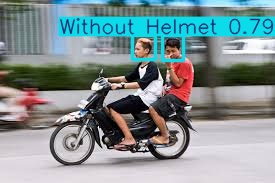

In [ ]:
from ultralytics import YOLO
from IPython.display import Image, display
import glob
import os

# Load model
model = YOLO("/content/runs/detect/train2/weights/best.pt")

# Input gambar test
img_path = "/content/foto comvis 2.jpg"

# Prediksi (YOLO akan buat folder predict2, predict3, dst)
results = model.predict(source=img_path, save=True)

# Cari folder prediksi terbaru
predict_dirs = sorted(glob.glob("runs/detect/predict*"), key=os.path.getmtime)
latest_pred_dir = predict_dirs[-1]

# Cari file gambar hasil prediksi terbaru
predicted_images = glob.glob(f"{latest_pred_dir}/*.jpg")

if predicted_images:
    print("Hasil deteksi terbaru ditampilkan:")
    display(Image(filename=predicted_images[0]))
else:
    print("Tidak ada hasil deteksi ditemukan!")